# Roblox Charts — Exploratory Data Analysis

798 games scraped from Roblox's Discover/charts surface (US, desktop).

Sections
1. Load & data quality
2. Feature preparation
3. How concentrated is attention?
4. The genre landscape
5. The Discover surface itself
6. Age ratings
7. Quality vs popularity
8. Game lifecycle
9. Creators & descriptions
10. Takeaways

## 1. Load & data quality

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---- plot style -------------------------------------------------------------
# One place for colour so every chart matches. Blue is the single-series
# default; the categorical slots are only used when a chart has 2-3 series.
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE    = "#e1e0d9", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
CAT = [BLUE, ORANGE, AQUA]
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlelocation": "left",
    "axes.titlepad": 12, "axes.labelsize": 10, "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "figure.dpi": 110, "savefig.bbox": "tight",
})

def thousands(ax, axis="x"):
    """Readable tick labels: 1.2B / 45M / 12K instead of 1.2e9."""
    def fmt(v, _):
        for div, suf in ((1e9, "B"), (1e6, "M"), (1e3, "K")):
            if abs(v) >= div:
                return f"{v/div:.0f}{suf}"
        return f"{v:.0f}"
    getattr(ax, f"{axis}axis").set_major_formatter(mticker.FuncFormatter(fmt))

def bar_labels(ax, bars, values, fmt="{:,.0f}", pad=3):
    """Direct-label horizontal bars; text stays ink-coloured, not series colour."""
    for b, v in zip(bars, values):
        ax.text(b.get_width() + pad, b.get_y() + b.get_height()/2,
                fmt.format(v), va="center", ha="left", fontsize=8, color=INK2)

In [2]:
raw = pd.read_csv("../data/games.csv", header= 0)
print(f" {raw.shape[0]} games x {raw.shape[1]} columns")
raw.head(3)

 798 games x 21 columns


,universe_id,name,description,genre,subgenre,content_maturity,minimum_age,sorts,sort_count,logo_url,...,creator_type,creator_id,playing,visits,favorites,up_votes,down_votes,max_players,created,updated
0,10563114921,Steal An Egg,🥚 Welcome to Steal An Egg!\n\nHow to Play:\n🥚 ...,Simulation,Tycoon,minimal,0,Top Trending | Top Playing Now | Top Revisited...,6,https://tr.rbxcdn.com/180DAY-856231c847a8d9709...,...,Group,825735094.0,1513929,1.999687e+09,2736250.0,1480536,106780,7.0,2026-07-25T07:50:51.492Z,2026-09-05T20:42:40.1911768Z
1,994732206,[🧲] Blox Fruits,OUT NOW: 🧲 Magnet + 🏝️ Sea 1 + MORE \nWelcome ...,RPG,Action RPG,mild,0,Top Trending | Top Playing Now | Top Revisited...,6,https://tr.rbxcdn.com/180DAY-774ec14539b264f85...,...,Group,4372130.0,284944,6.415630e+10,19844840.0,12626759,1055899,12.0,2019-01-16T03:29:19.433Z,2026-09-06T18:37:01.8890606Z
2,6035872082,[😾] RIVALS,"Welcome to RIVALS, the most intense first pers...",Shooter,Deathmatch Shooter,mild,0,Top Trending | Top Playing Now | Top Revisited...,6,https://tr.rbxcdn.com/180DAY-2f7bb0535e48ac376...,...,Group,3461453.0,113971,1.794642e+10,90792244.0,10505101,698084,40.0,2024-05-26T16:47:48.617Z,2026-09-07T03:27:39.211764Z


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   universe_id       798 non-null    int64  
 1   name              798 non-null    object 
 2   description       784 non-null    object 
 3   genre             791 non-null    object 
 4   subgenre          639 non-null    object 
 5   content_maturity  798 non-null    object 
 6   minimum_age       798 non-null    int64  
 7   sorts             798 non-null    object 
 8   sort_count        798 non-null    int64  
 9   logo_url          797 non-null    object 
 10  creator_name      786 non-null    object 
 11  creator_type      786 non-null    object 
 12  creator_id        786 non-null    float64
 13  playing           798 non-null    int64  
 14  visits            786 non-null    float64
 15  favorites         786 non-null    float64
 16  up_votes          798 non-null    int64  
 1

In [ ]:
# missing values by column, sorted descending
miss = pd.DataFrame({"missing": raw.isna().sum()}).sort_values("missing", ascending=False)
miss

,missing
subgenre,159
description,14
creator_name,12
creator_type,12
created,12
max_players,12
favorites,12
visits,12
creator_id,12
updated,12


`subgenre` is blank for ~20% of games 

The block of 12 identically-missing columns (`creator_*`, `visits`, `favorites`,
`max_players`, `created`, `updated`) -  details endpoint didn't return them 

In [17]:
detail_cols = ["creator_name", "visits", "favorites", "max_players", "created", "updated"]
raw.loc[raw[detail_cols].isna().all(axis=1), ["name", "playing", "sorts"]].head()

,name,playing,sorts
525,Break In 2 (Story),1716,Trending in Adventure
526,RV Cooked? [UPDATE ⛈️ 🚐],2753,Trending in Adventure
527,The Butchery,1230,Trending in Adventure
528,Mr.Mix,1658,Trending in Adventure
529,Ophelia [HORROR],1607,Trending in Adventure


These 12 rows with missing details, still have names and chart positions. -> Just exclude from any analysis that needs the details fields

In [18]:
# check for duplicate names
print("duplicate names:      ", raw.duplicated(["name"]).sum())

duplicate names:       0


In [20]:
raw.columns

Index(['universe_id', 'name', 'description', 'genre', 'subgenre',
       'content_maturity', 'minimum_age', 'sorts', 'sort_count', 'logo_url',
       'creator_name', 'creator_type', 'creator_id', 'playing', 'visits',
       'favorites', 'up_votes', 'down_votes', 'max_players', 'created',
       'updated'],
      dtype='object')

In [ ]:
numeric_cols = ['minimum_age', 'visits', 'favorites', 'playing', 'max_players', 'up_votes', 'down_votes']
pd.set_option('display.float_format', '{:.2f}'.format)
raw[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
minimum_age,798.00,0.02,0.42,0.00,0.00,0.00,0.00,12.00
visits,786.00,1108589132.41,5618654988.68,7466.00,9802360.00,68739554.50,359756628.75,87330520570.00
favorites,786.00,1742477.85,4957360.48,384.00,69974.50,301094.50,1263914.50,90792244.00
playing,798.00,7881.23,56868.26,0.00,272.00,1304.00,4464.50,1513929.00
max_players,786.00,25.41,41.44,1.00,10.00,18.00,30.00,700.00
up_votes,798.00,549930.29,1405180.37,58.00,18271.00,109324.00,452537.00,15393685.00
down_votes,798.00,53220.43,172311.83,4.00,2118.25,9229.50,29027.00,2662095.00


### How concentrated is the Roblox game engagement? -> Lorenz Curve for inequality

Are plays/visits/favorites spread fairly evenly across games, or do a small number of games get most of the attention?

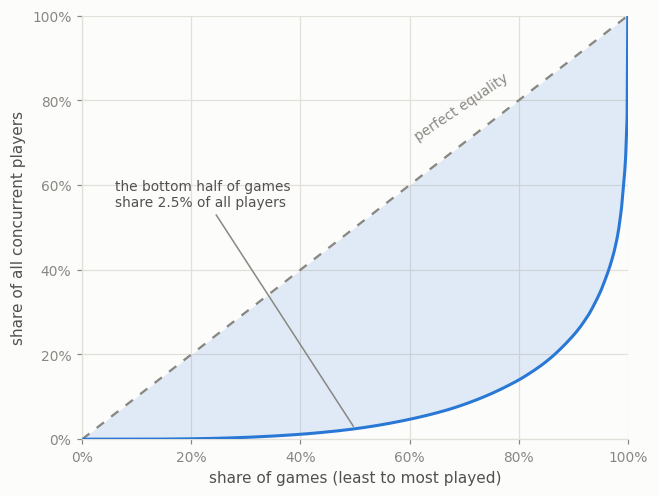

In [30]:
# Lorenz curve: x = share of games, y = share of all concurrent players.
# The further the curve sags below the diagonal, the more lopsided the catalog.
fig, ax = plt.subplots(figsize=(6.4, 5))

# sort in accending order (least-played game → most-played game), drop NaN
v = np.sort(raw["playing"].dropna().values)

# Y axis: cumulative player share = cumulative sum of each game's players / divided by totalplayers
cum = np.insert(np.cumsum(v) / v.sum(), 0, 0)

# X axis:cumulative share of games - creates evenly spaced values from 0 to 1.
share = np.linspace(0, 1, len(cum))

# equality line
# If every game had exactly the same number of players, your Lorenz curve would lie exactly on this line.
ax.plot([0, 1], [0, 1], color=MUTED, lw=1.5, ls=(0, (4, 4)), zorder=2)

# area shade
ax.fill_between(share, cum, share, color=BLUE, alpha=0.13, lw=0, zorder=1)
# actual lorenz curve
ax.plot(share, cum, color=BLUE, lw=2, zorder=3)

ax.text(0.62, 0.70, "perfect equality", color=MUTED, fontsize=9, rotation=34,
        rotation_mode="anchor", va="bottom")
ax.annotate(f"the bottom half of games\nshare {np.interp(0.5, share, cum):.1%} of all players",
            xy=(0.5, np.interp(0.5, share, cum)), xytext=(0.06, 0.55),
            fontsize=9, color=INK2,
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=1))

ax.set(xlim=(0, 1), ylim=(0, 1),
       xlabel="share of games (least to most played)",
       ylabel="share of all concurrent players")

ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
plt.show()

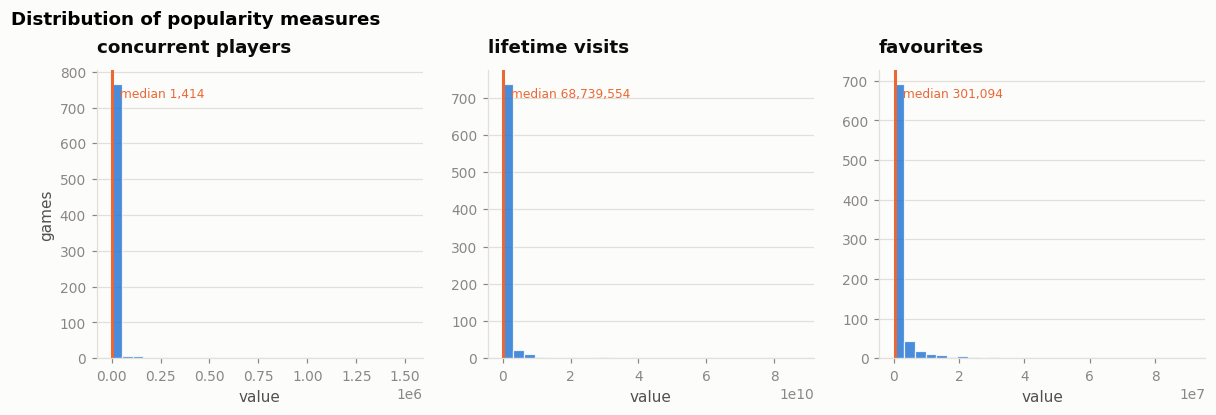

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for ax, col, label in zip(
    axes,
    ["playing", "visits", "favorites"],
    ["concurrent players", "lifetime visits", "favourites"]
):
    v = raw[col].dropna()
    v = v[v > 0]

    ax.hist(
        v,
        bins=28,
        color=BLUE,
        alpha=0.85,
        edgecolor=SURFACE,
        linewidth=0.8
    )

    ax.axvline(v.median(), color=ORANGE, lw=2)

    ax.text(
        v.median(),
        ax.get_ylim()[1] * 0.94,
        f"  median {v.median():,.0f}",
        color=ORANGE,
        fontsize=8,
        va="top"
    )

    ax.set(
        title=label,
        xlabel="value",
        ylabel="games" if col == "playing" else ""
    )

    ax.grid(axis="x", visible=False)

fig.suptitle(
    "Distribution of popularity measures",
    x=0.065,
    ha="left",
    fontsize=12,
    fontweight="semibold",
    y=1.04
)

plt.show()

This means most games have relatively low popularity, while a small number of games have extremely high popularity.

That's called a right-skewed distribution.

Concurrent players - Shows how many people are playing each game right now / at the time represented by your dataset.

A heavily skewed distribution means most games have relatively few concurrent players, while a small number attract huge audiences.

Lifetime visits - Shows the total accumulated visits each game has received.

A strong right tail means a few games have accumulated vastly more visits than most experiences.

Favourites - Shows how many users have favourited each game.

Again, a long right tail means a relatively small group of games receives a disproportionate amount of user inter

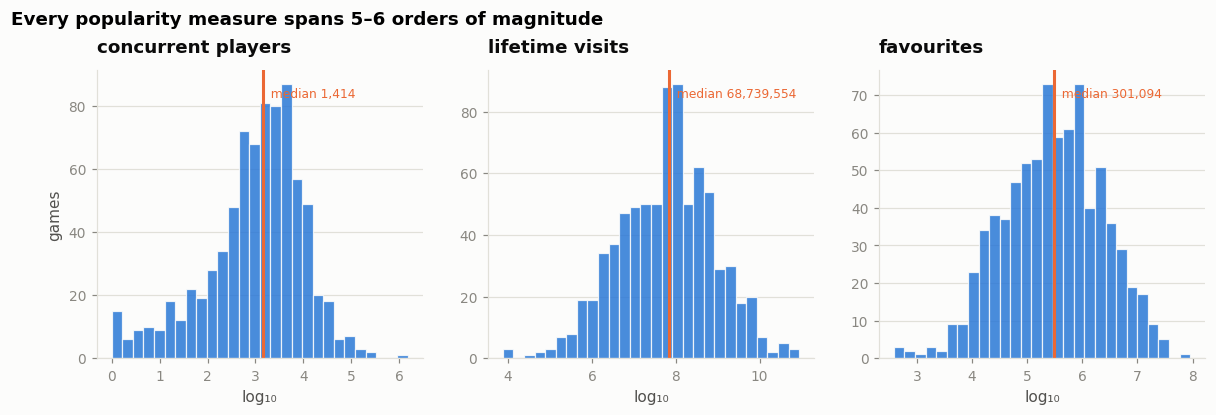

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

for ax, col, label in zip(
    axes,
    ["playing", "visits", "favorites"],
    ["concurrent players", "lifetime visits", "favourites"]
):
    v = raw[col].dropna()
    v = v[v > 0]

    # Histogram using log10-transformed values
    ax.hist(
        np.log10(v),
        bins=28,
        color=BLUE,
        alpha=0.85,
        edgecolor=SURFACE,
        linewidth=0.8
    )

    # Median line
    median_log = np.log10(v.median())
    ax.axvline(
        median_log,
        color=ORANGE,
        lw=2
    )

    # Median label
    ax.text(
        median_log,
        ax.get_ylim()[1] * 0.94,
        f"  median {v.median():,.0f}",
        color=ORANGE,
        fontsize=8,
        va="top"
    )

    ax.set(
        title=label,
        xlabel="log₁₀",
        ylabel="games" if col == "playing" else ""
    )

    ax.grid(axis="x", visible=False)

fig.suptitle(
    "Every popularity measure spans 5–6 orders of magnitude",
    x=0.065,
    ha="left",
    fontsize=12,
    fontweight="semibold",
    y=1.04
)

plt.show()

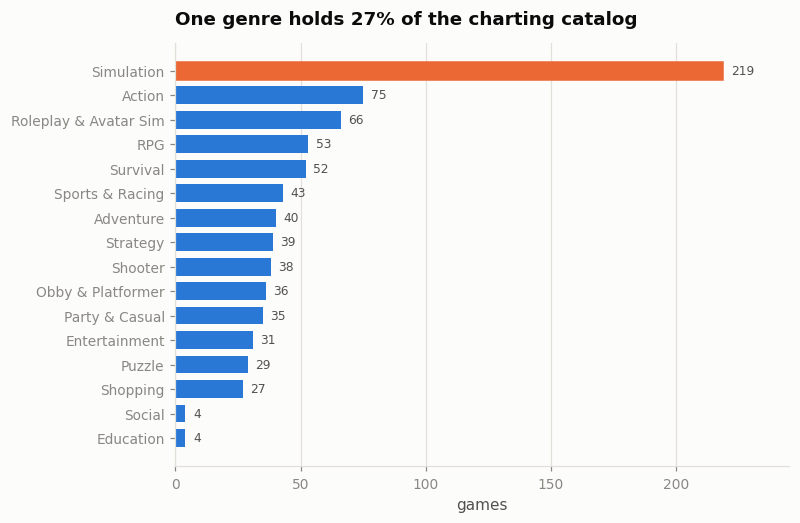

In [37]:
g = raw["genre"].value_counts()

fig, ax = plt.subplots(figsize=(7.2, 5))
bars = ax.barh(g.index[::-1], g.values[::-1], color=BLUE, height=0.72)
# highlight the outlier category rather than colouring every bar differently
bars[-1].set_color(ORANGE)
bar_labels(ax, bars, g.values[::-1])
ax.set(xlabel="games", ylabel="")
ax.set_title(f"One genre holds {g.iloc[0] / len(raw):.0%} of the charting catalog")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, g.max() * 1.12)
plt.show()

/var/folders/vs/ybxh3hyn7_7bpjzkl7xwj4700000gn/T/ipykernel_4580/3047745311.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=False, labels=keep.index, widths=0.6,


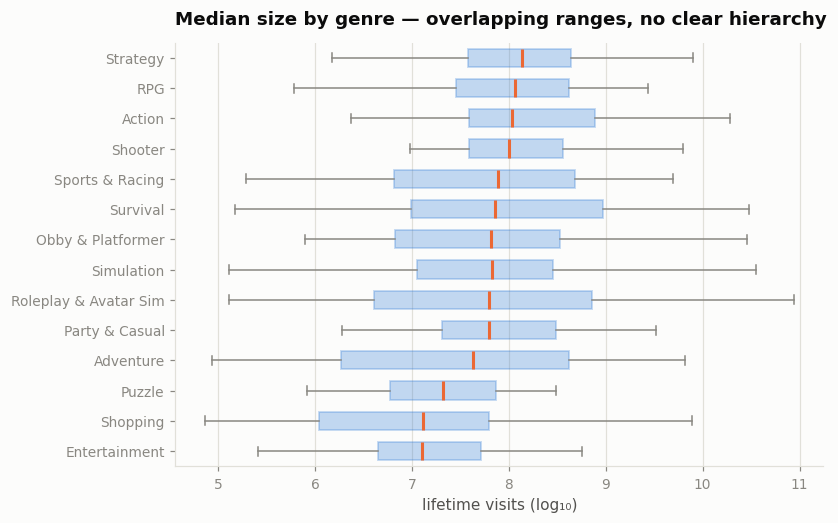

In [39]:
# Does genre predict how big a game gets? Ordered by median, so the chart
# answers the question rather than making you hunt for it.
sub = raw.dropna(subset=["genre", "visits"])
order = sub.groupby("genre")["visits"].median().sort_values()
keep = order[sub["genre"].value_counts().reindex(order.index) >= 10]

fig, ax = plt.subplots(figsize=(7.6, 5))
data = [np.log10(sub.loc[sub.genre == gname, "visits"].clip(lower=1)) for gname in keep.index]
bp = ax.boxplot(data, vert=False, labels=keep.index, widths=0.6,
                patch_artist=True, showfliers=False,
                medianprops=dict(color=ORANGE, lw=2),
                whiskerprops=dict(color=MUTED, lw=1),
                capprops=dict(color=MUTED, lw=1),
                boxprops=dict(facecolor=BLUE, alpha=0.28, edgecolor=BLUE, lw=1.2))
ax.set(xlabel="lifetime visits (log₁₀)", ylabel="")
ax.set_title("Median size by genre — overlapping ranges, no clear hierarchy")
ax.grid(axis="y", visible=False)
plt.show()

distinct sorts: 26   (raw value_counts would have shown 199 'sorts', which are really combinations)


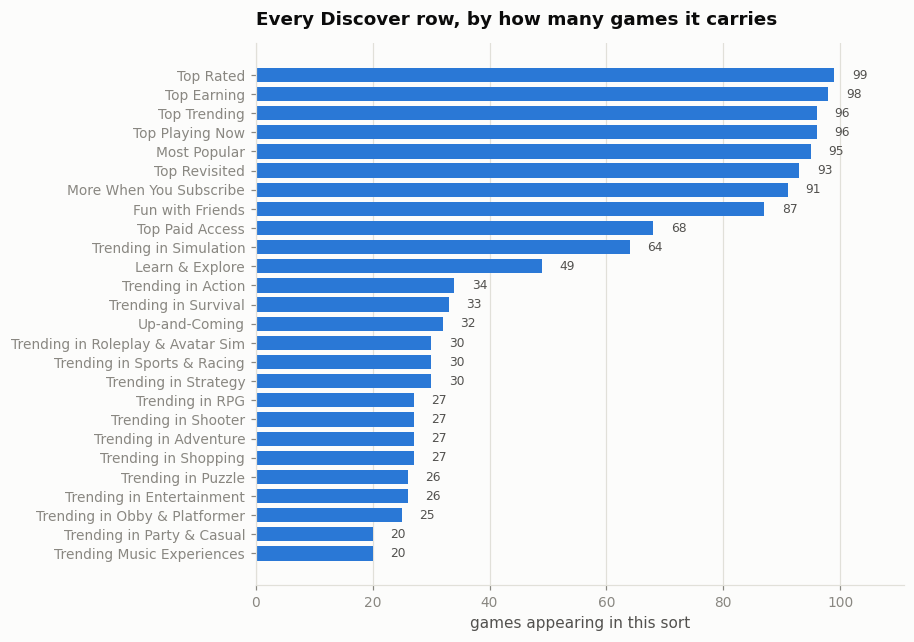

In [13]:
exploded = df.explode("sorts_list").dropna(subset=["sorts_list"])
sort_counts = exploded["sorts_list"].value_counts()
print(f"distinct sorts: {sort_counts.size}   (raw value_counts would have shown "
      f"{df['sorts'].nunique()} 'sorts', which are really combinations)")

fig, ax = plt.subplots(figsize=(7.6, 6.4))
bars = ax.barh(sort_counts.index[::-1], sort_counts.values[::-1], color=BLUE, height=0.74)
bar_labels(ax, bars, sort_counts.values[::-1])
ax.set(xlabel="games appearing in this sort", ylabel="")
ax.set_title("Every Discover row, by how many games it carries")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, sort_counts.max() * 1.12)
plt.show()

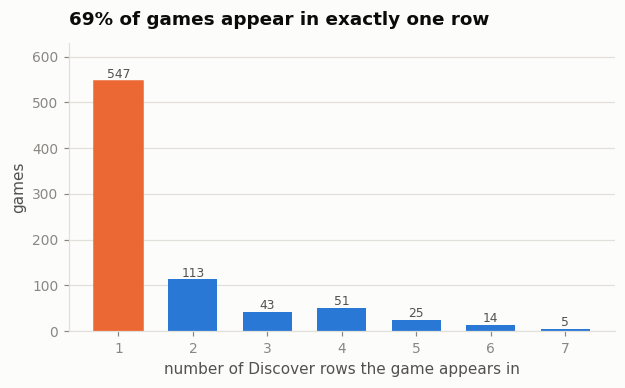

In [14]:
fig, ax = plt.subplots(figsize=(6.4, 3.4))
sc = df["sort_count"].value_counts().sort_index()
bars = ax.bar(sc.index, sc.values, color=BLUE, width=0.66)
bars[0].set_color(ORANGE)
for b, v in zip(bars, sc.values):
    ax.text(b.get_x() + b.get_width()/2, v + 6, f"{v}", ha="center",
            fontsize=8, color=INK2)
ax.set(xlabel="number of Discover rows the game appears in", ylabel="games")
ax.set_title(f"{sc.iloc[0]/len(df):.0%} of games appear in exactly one row")
ax.grid(axis="x", visible=False)
ax.set_ylim(0, sc.max() * 1.15)
plt.show()

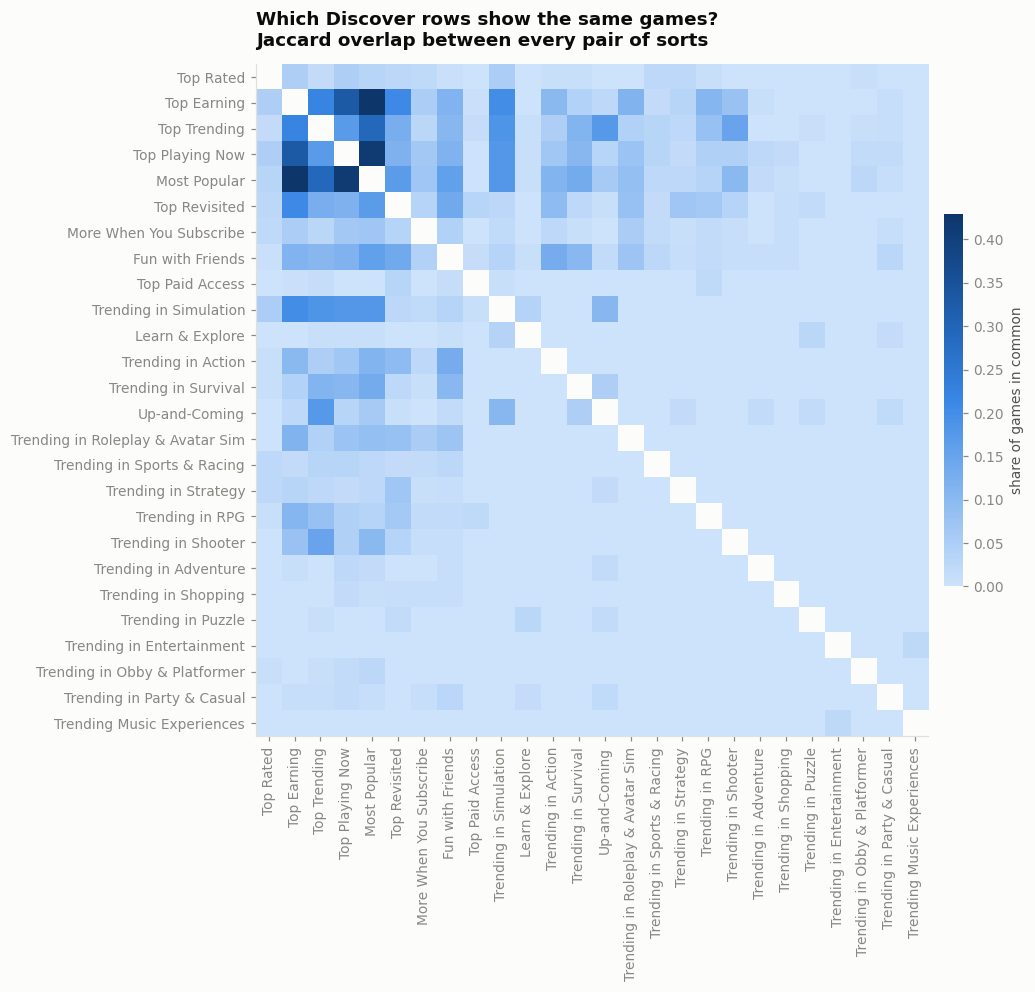

most redundant pairs of rows:
    43%  Top Earning  <->  Most Popular
    41%  Top Playing Now  <->  Most Popular
    33%  Top Earning  <->  Top Playing Now
    29%  Top Trending  <->  Most Popular
    22%  Top Earning  <->  Top Trending
    21%  Top Earning  <->  Top Revisited
    20%  Top Earning  <->  Trending in Simulation
    19%  Top Trending  <->  Trending in Simulation


In [15]:
# How redundant are the rows? Jaccard overlap between every pair of sorts.
names = sort_counts.index.tolist()
members = {s: set(exploded.loc[exploded.sorts_list == s, "universe_id"]) for s in names}
M = np.array([[len(members[a] & members[b]) / len(members[a] | members[b])
               for b in names] for a in names])
np.fill_diagonal(M, np.nan)

fig, ax = plt.subplots(figsize=(9.5, 8))
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("blues", BLUE_RAMP)
im = ax.imshow(M, cmap=cmap, vmin=0, vmax=np.nanmax(M))
ax.set_xticks(range(len(names)), names, rotation=90)
ax.set_yticks(range(len(names)), names)
ax.set_title("Which Discover rows show the same games?\nJaccard overlap between every pair of sorts")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.55, pad=0.02)
cb.set_label("share of games in common", color=INK2, fontsize=9)
cb.outline.set_visible(False)
plt.show()

pairs = [(names[i], names[j], M[i, j])
         for i in range(len(names)) for j in range(i+1, len(names))]
top = sorted(pairs, key=lambda p: -p[2])[:8]
print("most redundant pairs of rows:")
for a, b, v in top:
    print(f"  {v:5.0%}  {a}  <->  {b}")

## 6. Age ratings

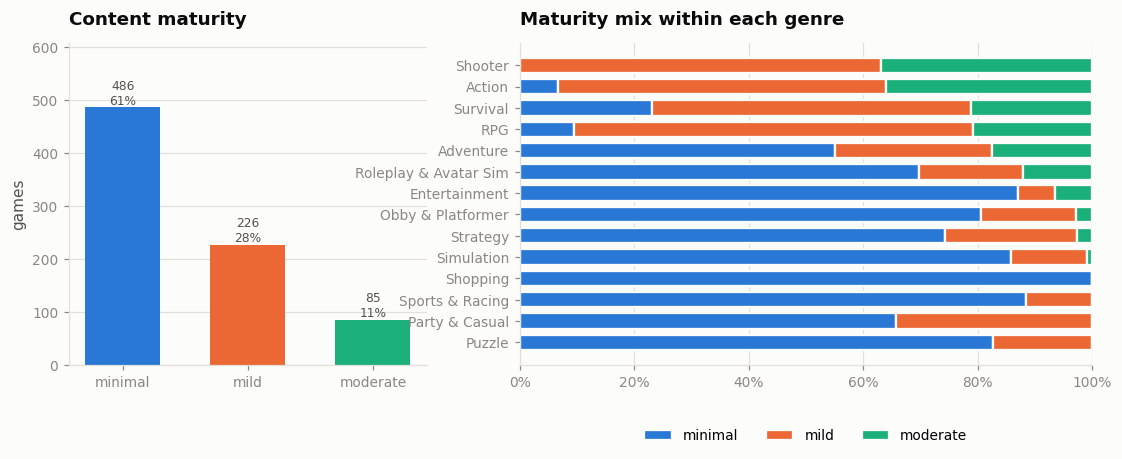

In [16]:
m = df["content_maturity"].value_counts()
m = m[m.index != "vng-rating-override"]          # single junk value

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), width_ratios=[1, 1.6])

bars = axes[0].bar(m.index, m.values, color=[CAT[i] for i in range(len(m))], width=0.6)
for b, v in zip(bars, m.values):
    axes[0].text(b.get_x() + b.get_width()/2, v + 6, f"{v}\n{v/len(df):.0%}",
                 ha="center", fontsize=8, color=INK2)
axes[0].set(ylabel="games", title="Content maturity")
axes[0].grid(axis="x", visible=False)
axes[0].set_ylim(0, m.max() * 1.25)

# maturity mix within each genre -- 3 series, so legend + stacked shares
ct = pd.crosstab(df["genre"], df["content_maturity"])
ct = ct[[c for c in ["minimal", "mild", "moderate"] if c in ct]]
ct = ct[ct.sum(axis=1) >= 10]
ct_pct = ct.div(ct.sum(axis=1), axis=0).sort_values("moderate")

left = np.zeros(len(ct_pct))
for i, col in enumerate(ct_pct.columns):
    axes[1].barh(ct_pct.index, ct_pct[col], left=left, color=CAT[i],
                 label=col, height=0.72, edgecolor=SURFACE, linewidth=1.5)
    left += ct_pct[col].values
axes[1].set(xlim=(0, 1), title="Maturity mix within each genre")
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
axes[1].legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, -0.28))
axes[1].grid(axis="y", visible=False)
plt.show()

This is the column that makes an age-aware map possible: **every** game carries a
maturity rating, with no missing values. A map can be *rendered* under an age
constraint rather than filtered after the fact.

## 7. Quality vs popularity

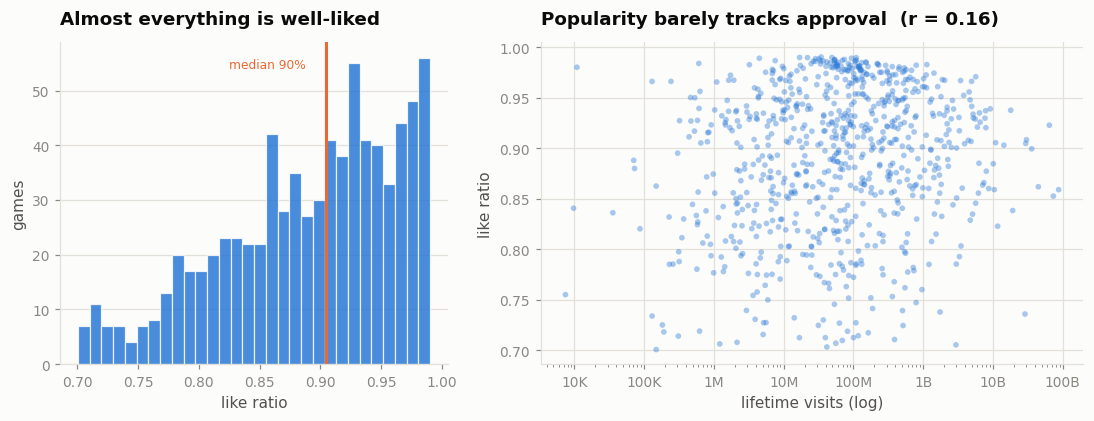

In [17]:
d = df.dropna(subset=["like_ratio", "visits"])
d = d[d.visits > 0]
r = np.corrcoef(np.log10(d.visits), d.like_ratio)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), width_ratios=[1, 1.4])

axes[0].hist(d["like_ratio"], bins=30, color=BLUE, alpha=0.85,
             edgecolor=SURFACE, linewidth=0.8)
axes[0].axvline(d["like_ratio"].median(), color=ORANGE, lw=2)
axes[0].text(d["like_ratio"].median() - 0.01, axes[0].get_ylim()[1]*0.95,
             f"median {d['like_ratio'].median():.0%}  ", color=ORANGE,
             fontsize=8, ha="right", va="top")
axes[0].set(xlabel="like ratio", ylabel="games", title="Almost everything is well-liked")
axes[0].grid(axis="x", visible=False)

axes[1].scatter(d["visits"], d["like_ratio"], s=14, color=BLUE, alpha=0.4,
                edgecolors="none")
axes[1].set_xscale("log")
axes[1].set(xlabel="lifetime visits (log)", ylabel="like ratio",
            title=f"Popularity barely tracks approval  (r = {r:.2f})")
thousands(axes[1])
plt.show()

Two things follow. The like ratio is squashed against the ceiling — median ~90%,
so it barely discriminates. And it's almost **uncorrelated with popularity**, which
means popularity is not a proxy for quality. If node size on the map used plays
alone, the map would just re-draw the popularity chart.

## 8. Game lifecycle

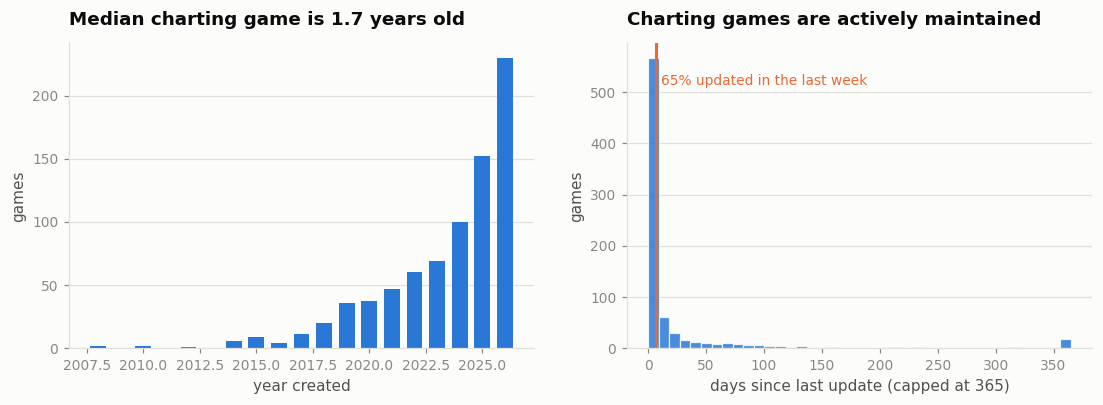

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

years = df["created"].dt.year.dropna().astype(int)
vc = years.value_counts().sort_index()
bars = axes[0].bar(vc.index, vc.values, color=BLUE, width=0.7)
axes[0].set(xlabel="year created", ylabel="games",
            title=f"Median charting game is {df['age_years'].median():.1f} years old")
axes[0].grid(axis="x", visible=False)

dsu = df["days_since_update"].dropna().clip(0, 365)
axes[1].hist(dsu, bins=40, color=BLUE, alpha=0.85, edgecolor=SURFACE, linewidth=0.8)
fresh = (df["days_since_update"] < 7).mean()
axes[1].axvline(7, color=ORANGE, lw=2)
axes[1].text(11, axes[1].get_ylim()[1]*0.9, f"{fresh:.0%} updated in the last week",
             color=ORANGE, fontsize=9, va="top")
axes[1].set(xlabel="days since last update (capped at 365)", ylabel="games",
            title="Charting games are actively maintained")
axes[1].grid(axis="x", visible=False)
plt.show()

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 127798 (\N{HOT PEPPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


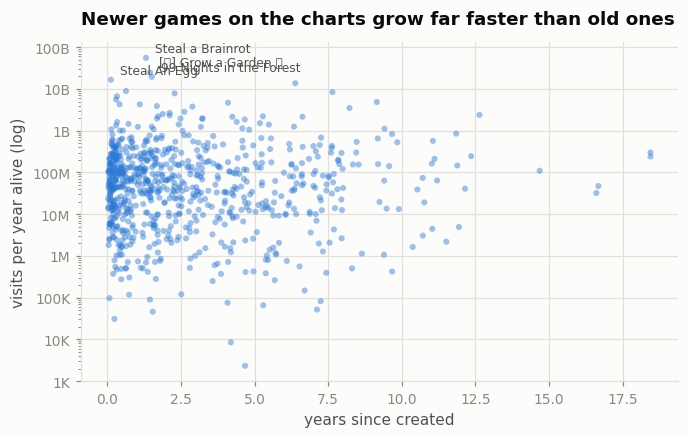

In [19]:
# Does age buy you visits, or is speed of growth its own thing?
d = df.dropna(subset=["age_years", "visits_per_year"])
d = d[d.visits_per_year > 0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(d["age_years"], d["visits_per_year"], s=16, color=BLUE,
           alpha=0.45, edgecolors="none")
ax.set_yscale("log")
ax.set(xlabel="years since created", ylabel="visits per year alive (log)",
       title="Newer games on the charts grow far faster than old ones")
thousands(ax, "y")
for _, row in d.nlargest(4, "visits_per_year").iterrows():
    ax.annotate(row["name"][:24], (row["age_years"], row["visits_per_year"]),
                fontsize=8, color=INK2, xytext=(6, 4), textcoords="offset points")
plt.show()

## 9. Creators & descriptions

In [20]:
cre = df["creator_name"].value_counts()
multi = cre[cre > 1]
print(f"distinct creators:            {cre.size}")
print(f"creators with >1 charting game: {multi.size}  (covering {multi.sum()} games, "
      f"{multi.sum()/len(df):.0%} of the catalog)")
print("\ntop creators on the charts:")
print(multi.head(8).to_string())

distinct creators:            758
creators with >1 charting game: 24  (covering 52 games, 7% of the catalog)

top creators on the charts:
creator_name
Sonar Studios      4
Context Works      4
C:\Games\          2
captainwoodlegs    2
Absolute Zero!     2
Trite Roleplay     2
Rumble Studios     2
bLockerman666      2


Only a small share of games share a creator with another charting game, so
**shared-creator links are too sparse to carry a graph on their own** — useful as a
secondary signal, not a backbone.

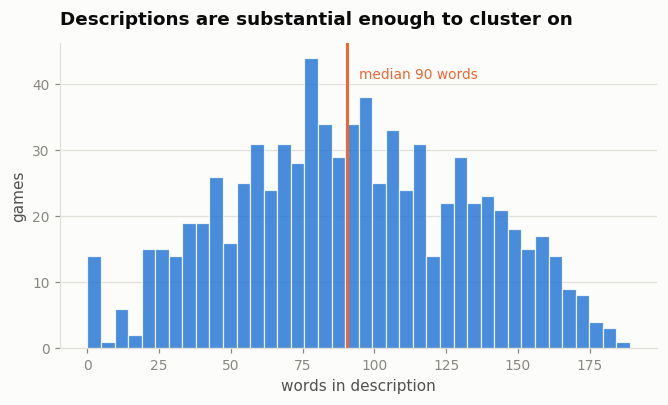

empty descriptions: 14
under 20 words:     25


In [21]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(df["desc_words"], bins=40, color=BLUE, alpha=0.85,
        edgecolor=SURFACE, linewidth=0.8)
ax.axvline(df["desc_words"].median(), color=ORANGE, lw=2)
ax.text(df["desc_words"].median() + 4, ax.get_ylim()[1]*0.92,
        f"median {df['desc_words'].median():.0f} words", color=ORANGE, fontsize=9, va="top")
ax.set(xlabel="words in description", ylabel="games",
       title="Descriptions are substantial enough to cluster on")
ax.grid(axis="x", visible=False)
plt.show()

print(f"empty descriptions: {(df.desc_words == 0).sum()}")
print(f"under 20 words:     {(df.desc_words < 20).sum()}")

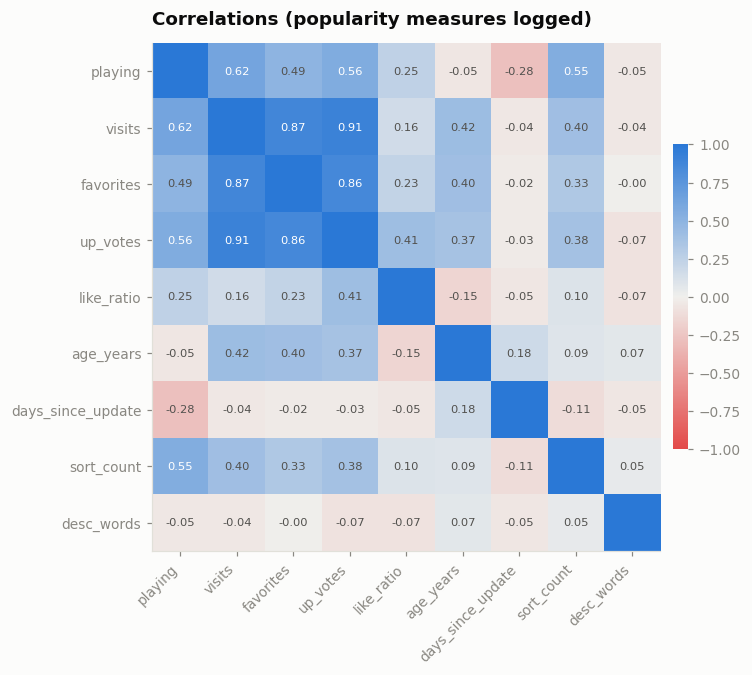

In [22]:
# Correlation among the real measures (identifiers excluded on purpose)
cols = ["playing", "visits", "favorites", "up_votes", "like_ratio",
        "age_years", "days_since_update", "sort_count", "desc_words"]
corr = df[cols].apply(lambda s: np.log1p(s) if s.name in
                      ("playing", "visits", "favorites", "up_votes") else s).corr()

fig, ax = plt.subplots(figsize=(7.4, 6))
from matplotlib.colors import LinearSegmentedColormap
div = LinearSegmentedColormap.from_list("div", ["#e34948", "#f0efec", "#2a78d6"])
im = ax.imshow(corr, cmap=div, vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=45, ha="right")
ax.set_yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        if i != j:
            ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center",
                    fontsize=7.5,
                    color="white" if abs(corr.iloc[i, j]) > 0.55 else INK2)
ax.set_title("Correlations (popularity measures logged)")
ax.grid(False)
cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cb.outline.set_visible(False)
plt.show()

## 10. Takeaways

**Attention is extremely concentrated.** Gini ~0.84 on concurrent players; the top
1% of games take ~43% of all players and the top 10% take ~75%. This is the core
argument for a map over a feed — a ranked list will always show the same handful.

**Roblox's genre labels are weak.** One label covers ~27% of the catalog, and median
size by genre overlaps heavily, so genre predicts neither what a game *is* nor how
big it gets. Room for discovered structure to beat declared structure.

**The Discover rows are redundant with each other.** The overlap heatmap shows
several pairs sharing a large share of their games — the surface is narrower than
its 26 rows suggest.

**Popularity is not quality.** Like ratio is squashed near 90% and barely correlates
with visits, so node size on any map should not be plays alone.

**Age ratings are complete.** Every game has a maturity rating with zero missing
values — an age-constrained view is buildable today.

**Descriptions are good enough to cluster.** Median ~90 words of real text, only 14
empty. Text is a viable backbone; shared-creator links are too sparse to be one.

### Next
Feature engineering on the cleaned description text, then embeddings and clustering
to test whether discovered neighbourhoods beat the genre labels.